In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


Rows Columns
(1000, 13)
   age  gender  chestpain  restingBP  serumcholestrol  fastingbloodsugar  \
0   53       1          2        171                0                  0   
1   40       1          0         94              229                  0   
2   49       1          2        133              142                  0   
3   43       1          0        138              295                  1   
4   31       1          1        199                0                  0   

   restingrelectro  maxheartrate  exerciseangia  oldpeak  slope  \
0                1           147              0      5.3      3   
1                1           115              0      3.7      1   
2                0           202              1      5.0      1   
3                1           153              0      3.2      2   
4                2           136              0      5.3      3   

   noofmajorvessels  class  
0                 3      1  
1                 1      0  
2                 0      0  

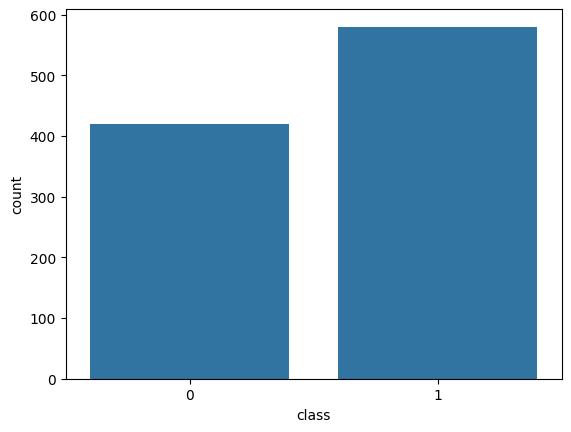

In [2]:
#Read and Display Data Set

#First, read in CSV and assign it to a variable called "data"
data = pd.read_csv("data/heart_disease.csv")

#Second, display maximum rows and columns
print('\nRows Columns') #Indicates rows and columns
print(data.shape) #gets the number of rows and columns of data set

pd.set_option('display.max_columns', None) #optional setting to show all feature columns

#Third, display first five rows to check data
print(data.head(5))

#Select last column (assuming the last column is the class)
last_column = data.iloc[:, -1] #using iloc to select the last column

#Count occurences of 0's and 1's
value_counts = last_column.value_counts()

#Print the value counts and check for imbalance
print('\n' , value_counts)

sns.countplot(x="class", data=data)
plt.show()

In [3]:
#Declare X and Y Variables and Split the Dataset into Train and Test sections
X=data.drop(['class'], axis=1).values #X Variables = all common except the last one

#Declare last column to be the Dependent variable Y
y=data['class'].values #Y Variable = last column

#Split Data Set 70% training and 30% Testing. Initial data shuffle to zero
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7,test_size=0.3, random_state=0)

In [4]:
#Create and Test the Model

#First, declare a new model
classifier_model = DecisionTreeClassifier()

#Second, Train (fit) the model from the training data
classifier_model.fit(X_train, y_train)

#Fourth, Test the model using the testing data
y_pred = classifier_model.predict(X_test)
print('\nTest Data Model = ', y_pred)


Test Data Model =  [0 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 1 1 1
 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 0 0 0 0 0
 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1
 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1
 1 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0
 1 0 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 1 0 0
 1 1 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 0 1
 0 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 1 1 1 0 0 0 1 1 0 1
 1 0 0 1]


In [4]:
#Create and test random forest model
from sklearn.ensemble import RandomForestClassifier as RandomForest
rf = RandomForest(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('\nRandom Forest Model = ', y_pred_rf)

#Evaluate the Model
from sklearn.metrics import classification_report
print('\nDecision Tree Classifier Model')
print(classification_report(y_test, y_pred_rf))
print('\naccuracy_score = ', accuracy_score(y_test, y_pred_rf))
print('precision_score = ', precision_score(y_test, y_pred_rf))
print('recall_score = ', recall_score(y_test, y_pred_rf))
print('f1_score = ', f1_score(y_test, y_pred_rf))
print('confusion_matrix = ', confusion_matrix(y_test, y_pred_rf))



Random Forest Model =  [1 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 1 1 1
 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 0 0 0 0 0
 0 1 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1
 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1
 1 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 0 0 0 0
 1 0 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 0
 1 1 0 0 0 0 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 0 1
 0 1 1 1 0 1 1 0 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 1 1 1 0 0 0 1 1 0 1
 1 0 0 1]

Decision Tree Classifier Model
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       139
           1       0.98      0.98      0.98       161

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300


accura


Confusion Matrix = 
 [[135   4]
 [ 10 151]]

Accuracy =  0.9533333333333334

Precision =  0.9741935483870968

Recall =  0.937888198757764

F1 Score =  0.9556962025316456


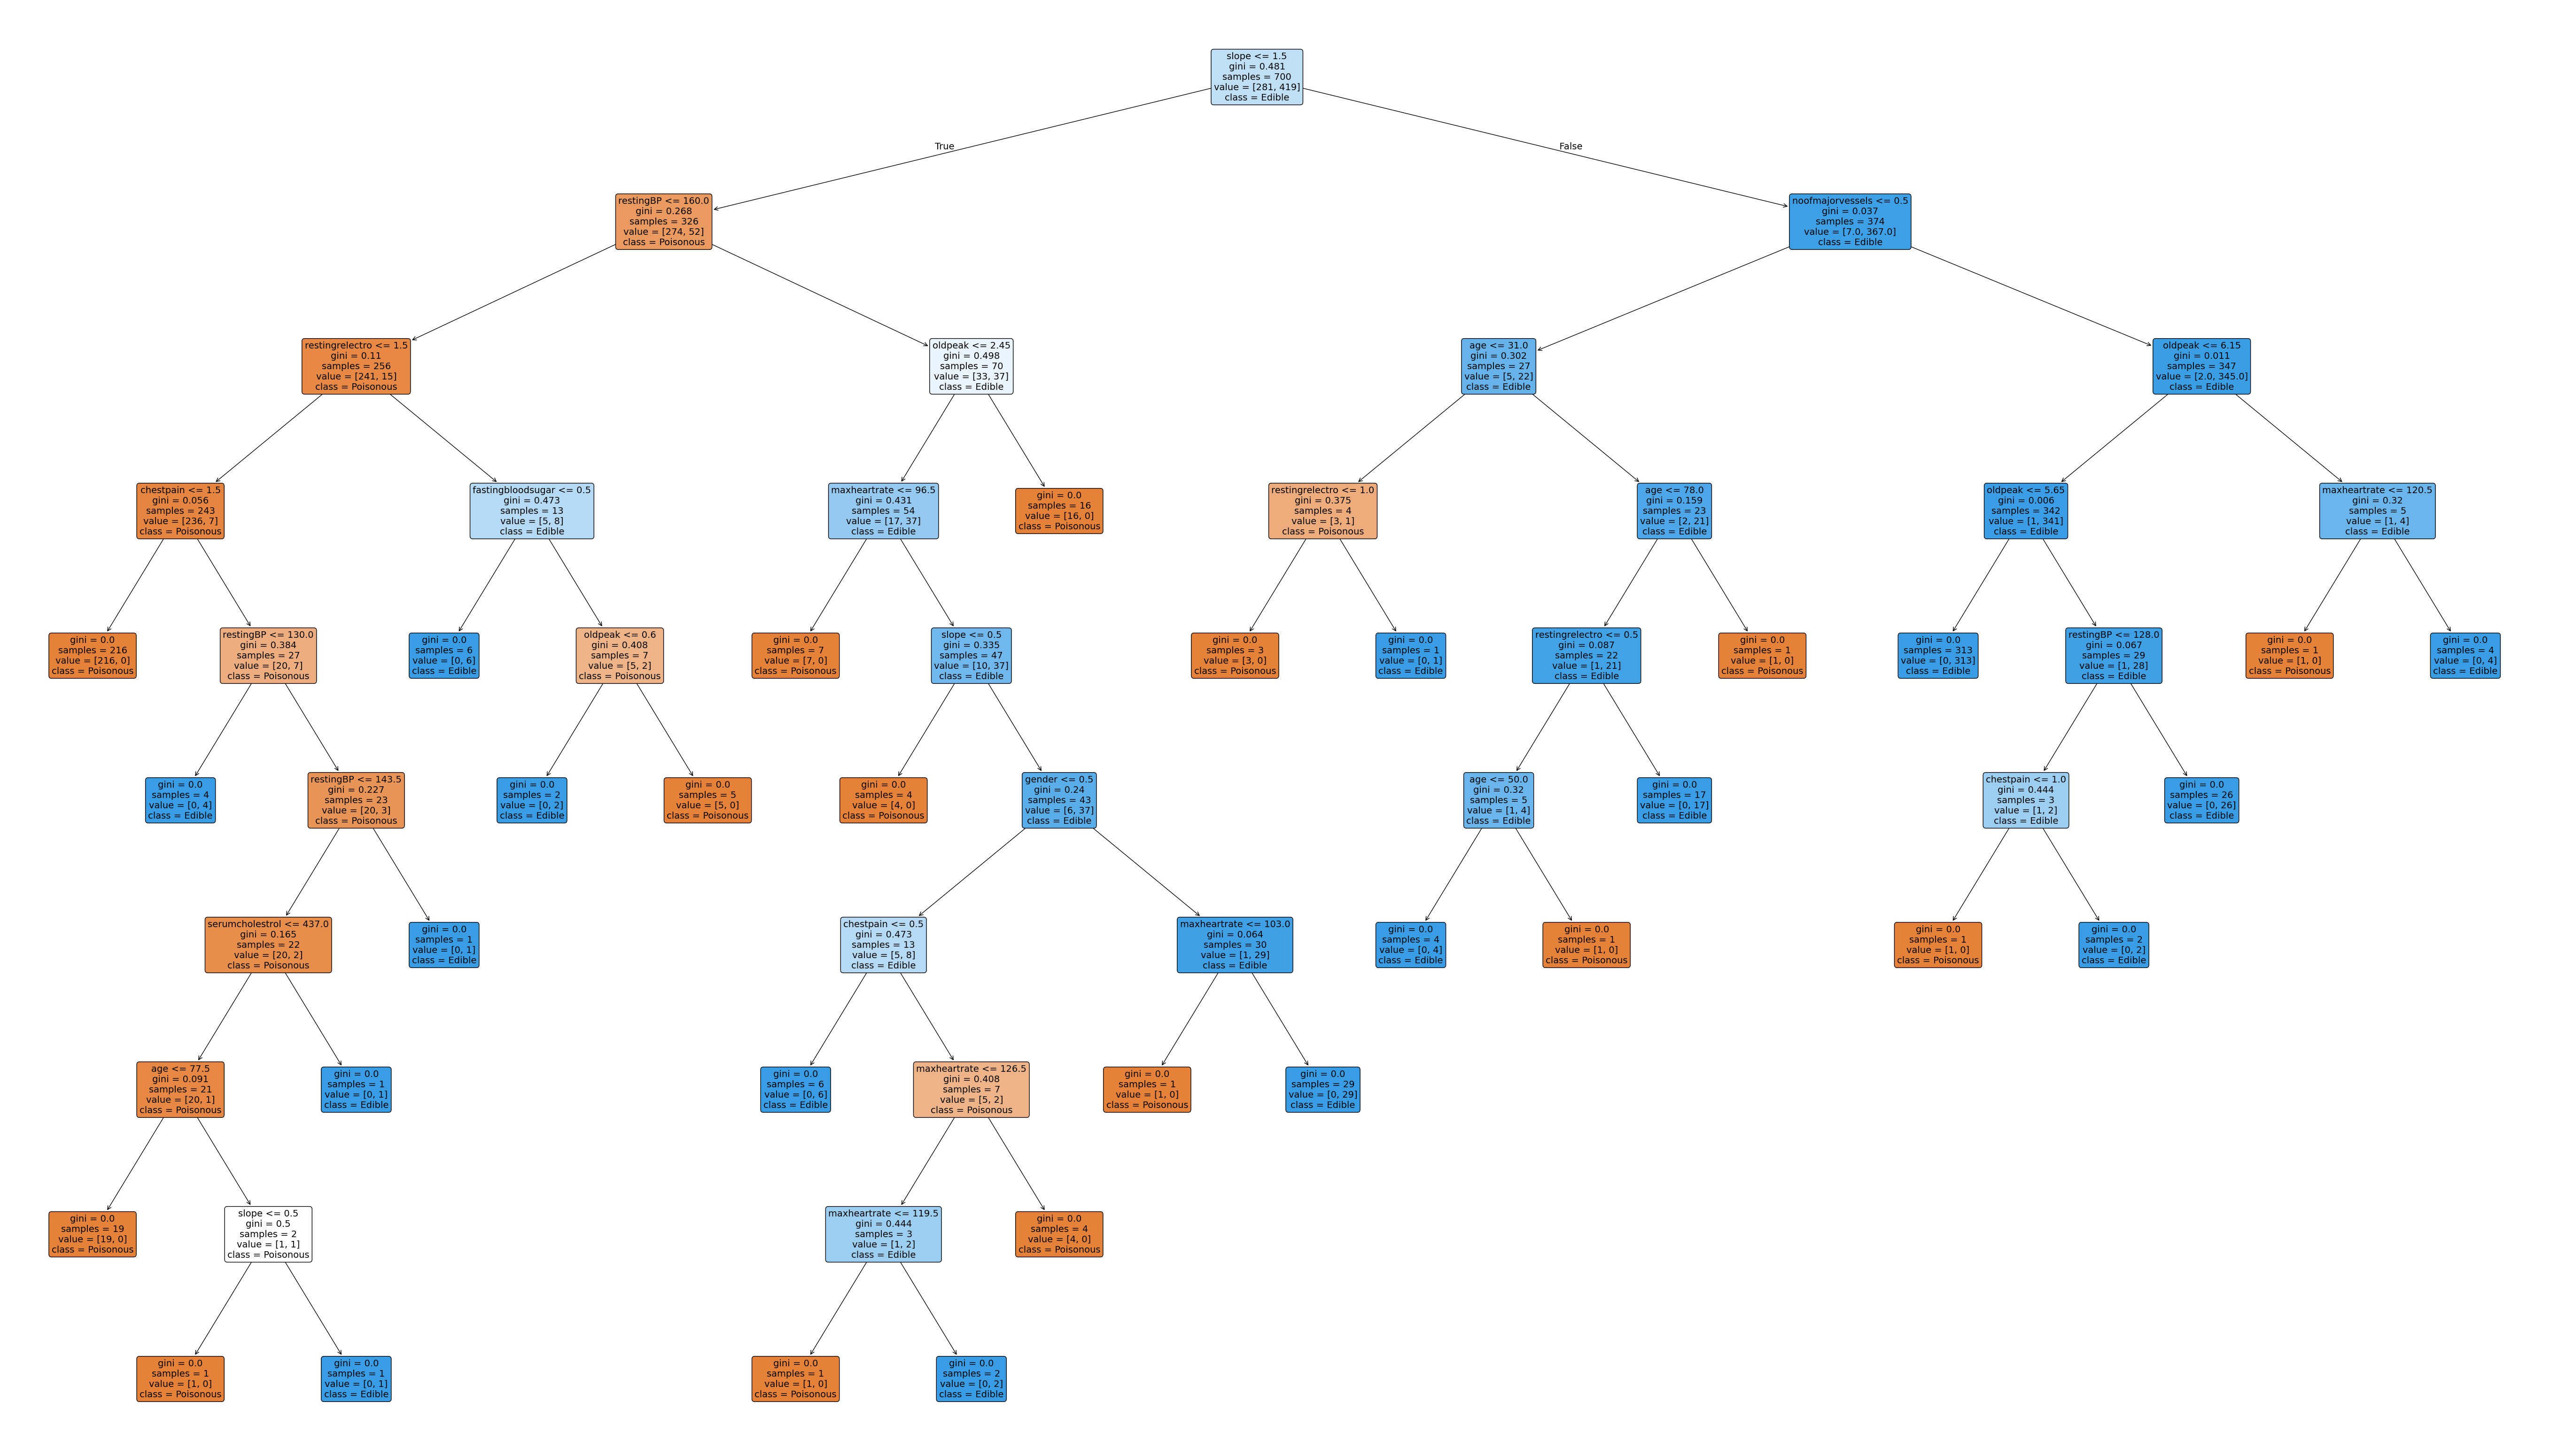

In [5]:
#Evaluate Model
print('\nConfusion Matrix = \n', confusion_matrix(y_test, y_pred))
print('\nAccuracy = ', accuracy_score(y_test, y_pred))
print('\nPrecision = ', precision_score(y_test, y_pred))
print('\nRecall = ', recall_score(y_test, y_pred))
print('\nF1 Score = ', f1_score(y_test, y_pred))

#Print out shape of tree
from sklearn.tree import _tree, plot_tree
plt.figure('Decision Tree', figsize=(70,40))
plot_tree(classifier_model, filled=True, rounded=True, fontsize=14, feature_names=data.columns, class_names=['Poisonous','Edible'])
plt.show()